In [ ]:
!pip install catboost -q
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 21.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [ ]:
import os
import random
#import ee
import re
import ast
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LinearRegression


import catboost as catt
import xgboost as xgb
import lightgbm as lgb
import optuna
import torch

le = LabelEncoder()

import warnings
warnings.filterwarnings("ignore")

In [ ]:
def seed_torch(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.enabled = True

seed_torch(2)

In [ ]:
old_path = "/content/drive/MyDrive/cote-divoire-byte-sized-agriculture-challenge20250425-32468-eojlf0/"
new_path = "/content/drive/MyDrive/cotedivoire_cyber_updated/"
orig_train = pd.read_csv("/content/drive/MyDrive/cotedivoire_cyber_updated/TrainDataset.csv")
train = pd.read_csv(new_path + "train_monthly_stats_patch_8.csv")
test = pd.read_csv(new_path + "test_monthly_stats_patch_8.csv")

sub = pd.read_csv(new_path + "SampleSubmission.csv")
display(train.head(), train.shape, test.head(), test.shape,orig_train.head())

,ID,B1_mean_Jan,B1_mean_Feb,B1_mean_Mar,B1_mean_Apr,B1_mean_May,B1_mean_Jun,B1_mean_Jul,B1_mean_Aug,B1_mean_Sep,...,B12_std_Mar,B12_std_Apr,B12_std_May,B12_std_Jun,B12_std_Jul,B12_std_Aug,B12_std_Sep,B12_std_Oct,B12_std_Nov,B12_std_Dec
0,ID_h14T0B,2572.0000,2717.3333,4040.1110,2776.7778,NaN,NaN,2464.222168,NaN,NaN,...,468.751500,133.086210,NaN,NaN,165.486435,NaN,NaN,NaN,604.955000,137.153530
1,ID_KbyKOr,2525.7778,2504.8518,2461.6667,3293.5186,NaN,9009.814453,3899.111084,NaN,NaN,...,13.436127,122.446236,NaN,329.056305,143.045563,NaN,NaN,NaN,75.820110,16.822327
2,ID_t4Tmmn,2524.9507,2637.3210,2693.1110,4337.9750,NaN,5410.654297,5059.666504,NaN,NaN,...,294.548430,418.674900,NaN,368.014557,91.788902,NaN,NaN,NaN,26.631258,34.288170
3,ID_yipWoC,2548.7778,2513.5557,2504.6667,3261.8890,NaN,9243.555664,4270.222168,NaN,NaN,...,44.584770,108.203320,NaN,108.737442,257.078369,NaN,NaN,NaN,160.144880,21.252405
4,ID_XKiksa,2550.3333,2534.8025,4444.1480,6013.1357,NaN,NaN,2388.728516,NaN,NaN,...,221.105930,274.404570,NaN,NaN,158.157867,NaN,NaN,NaN,351.091740,26.783396


(953, 721)

,ID,B1_mean_Jan,B1_mean_Feb,B1_mean_Mar,B1_mean_Apr,B1_mean_May,B1_mean_Jun,B1_mean_Jul,B1_mean_Aug,B1_mean_Sep,...,B12_std_Mar,B12_std_Apr,B12_std_May,B12_std_Jun,B12_std_Jul,B12_std_Aug,B12_std_Sep,B12_std_Oct,B12_std_Nov,B12_std_Dec
0,ID_731818,3675.3828,6254.7656,2331.5432,2560.0740,NaN,NaN,3022.555664,NaN,NaN,...,121.37636,133.43044,NaN,NaN,414.233673,NaN,NaN,NaN,375.903230,120.210320
1,ID_790093,2587.5803,2612.5803,4692.8150,2633.0000,NaN,NaN,3264.543213,NaN,NaN,...,678.30756,79.13994,NaN,NaN,686.098206,NaN,NaN,NaN,154.914370,46.440422
2,ID_931033,2494.2593,2466.6296,3142.5186,3918.4443,NaN,NaN,5033.296387,NaN,NaN,...,446.23862,141.93504,NaN,NaN,526.388367,NaN,NaN,NaN,125.964810,24.086151
3,ID_079024,2546.9630,6655.6790,7731.1113,2260.1482,NaN,NaN,5303.987793,NaN,NaN,...,243.72792,64.41247,NaN,NaN,286.093079,NaN,NaN,NaN,83.257034,30.485320
4,ID_691532,2490.8147,3853.9260,2445.5925,2781.4443,NaN,3631.666748,5187.444336,NaN,NaN,...,152.02348,237.13728,NaN,342.428711,124.847565,NaN,NaN,NaN,525.197900,43.920370


(282, 721)

,ID,year,month,tifPath,Target,class
0,ID_h14T0B_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3
1,ID_KbyKOr_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3
2,ID_t4Tmmn_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3
3,ID_yipWoC_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3
4,ID_XKiksa_Jan,2024,Jan,/content/drive/MyDrive/train_s2_images_new_fin...,Rubber,3


In [ ]:

def normalize_id(id_str):
    return re.sub(r'_[A-Za-z]+$', '', id_str)

orig_train['Base_ID'] = orig_train['ID'].apply(normalize_id)

In [ ]:
grouped_train = pd.DataFrame(orig_train.groupby('Base_ID')['Target'].apply(lambda x: x.mode().iloc[0])).reset_index()

train = pd.merge(train, grouped_train, left_on='ID', right_on='Base_ID', how='left')
train.drop('Base_ID', axis=1, inplace=True)
train.rename(columns={'Target': 'crop'}, inplace=True)
train.head()

,ID,B1_mean_Jan,B1_mean_Feb,B1_mean_Mar,B1_mean_Apr,B1_mean_May,B1_mean_Jun,B1_mean_Jul,B1_mean_Aug,B1_mean_Sep,...,B12_std_Apr,B12_std_May,B12_std_Jun,B12_std_Jul,B12_std_Aug,B12_std_Sep,B12_std_Oct,B12_std_Nov,B12_std_Dec,crop
0,ID_h14T0B,2572.0000,2717.3333,4040.1110,2776.7778,NaN,NaN,2464.222168,NaN,NaN,...,133.086210,NaN,NaN,165.486435,NaN,NaN,NaN,604.955000,137.153530,Rubber
1,ID_KbyKOr,2525.7778,2504.8518,2461.6667,3293.5186,NaN,9009.814453,3899.111084,NaN,NaN,...,122.446236,NaN,329.056305,143.045563,NaN,NaN,NaN,75.820110,16.822327,Rubber
2,ID_t4Tmmn,2524.9507,2637.3210,2693.1110,4337.9750,NaN,5410.654297,5059.666504,NaN,NaN,...,418.674900,NaN,368.014557,91.788902,NaN,NaN,NaN,26.631258,34.288170,Rubber
3,ID_yipWoC,2548.7778,2513.5557,2504.6667,3261.8890,NaN,9243.555664,4270.222168,NaN,NaN,...,108.203320,NaN,108.737442,257.078369,NaN,NaN,NaN,160.144880,21.252405,Rubber
4,ID_XKiksa,2550.3333,2534.8025,4444.1480,6013.1357,NaN,NaN,2388.728516,NaN,NaN,...,274.404570,NaN,NaN,158.157867,NaN,NaN,NaN,351.091740,26.783396,Rubber


In [ ]:
drop_cols = list(set(test.columns) - set(train.columns))
drop_cols

[]

In [ ]:
train['crop'].value_counts()

,count
crop,
Rubber,405
Palm,313
Cocoa,235


### FEAUTURE ENGINEERING

In [ ]:

def get_high_null_columns(df, thresh=0.9):
    """
    Returns a list of columns with proportion of missing values greater than the threshold.

    Parameters:
    - df (pd.DataFrame): Input DataFrame.
    - thresh (float): Threshold for missing value ratio (e.g., 0.9 means 90%).

    Returns:
    - List[str]: Columns to drop.
    """
    null_ratios = df.isnull().mean()
    return null_ratios[null_ratios > thresh].index.tolist()

def compute_dynamic_vegetation_indices(df, stats_to_include=None):
    """
    Compute multiple vegetation indices dynamically across stats (e.g., mean, median) and months.

    Parameters:
    - df: pandas DataFrame with columns like 'B8_mean_Jan'
    - stats_to_include: list like ['mean', 'median']; if None, include all available

    Returns:
    - df with new vegetation index columns
    """
    import re
    from collections import defaultdict

    pattern = re.compile(r'B(\d+)_(\w+)_([A-Za-z]+)')
    bands_by_stat_month = defaultdict(lambda: defaultdict(dict))  # {stat: {month: {band: column}}}

    # Map bands to columns
    for col in df.columns:
        match = pattern.fullmatch(col)
        if match:
            band, stat, month = match.groups()
            if stats_to_include is None or stat in stats_to_include:
                bands_by_stat_month[stat][month][f'B{band}'] = col

    # Vegetation index formulas
    def compute_indices(df, band_cols):
        indices = {}
        eps = 1e-6
        L = 0.5  # SAVI soil brightness correction factor

        B = lambda b: df[band_cols[b]] if b in band_cols else None

        if B('B8') is not None and B('B4') is not None:
            indices['NDVI'] = (B('B8') - B('B4')) / (B('B8') + B('B4') + eps)

        if B('B8') is not None and B('B4') is not None and B('B2') is not None:
            indices['EVI'] = 2.5 * (B('B8') - B('B4')) / (B('B8') + 6 * B('B4') - 7.5 * B('B2') + 1 + eps)

        if B('B3') is not None and B('B11') is not None:
            indices['NDWI'] = (B('B3') - B('B11')) / (B('B3') + B('B11') + eps)

        if B('B8') is not None and B('B4') is not None:
            indices['SAVI'] = ((B('B8') - B('B4')) * (1 + L)) / (B('B8') + B('B4') + L + eps)

        if B('B8') is not None and B('B12') is not None:
            indices['NBR'] = (B('B8') - B('B12')) / (B('B8') + B('B12') + eps)

        if B('B11') is not None and B('B8') is not None:
            indices['MSI'] = B('B11') / (B('B8') + eps)

        if B('B8') is not None and B('B3') is not None:
            indices['GCI'] = (B('B8') / (B('B3') + eps)) - 1

        if B('B8') is not None and B('B3') is not None:
            indices['GNDVI'] = (B('B8') - B('B3')) / (B('B8') + B('B3') + eps)

        return indices

    # Add indices to dataframe
    for stat, months in bands_by_stat_month.items():
        for month, band_cols in months.items():
            computed = compute_indices(df, band_cols)
            for idx_name, values in computed.items():
                df[f"{idx_name}_{stat}_{month}"] = values

    return df


def create_monthly_diff_features(df, bands, stats, months):
    """
    Create differential features like diff_B1_mean_1 = B1_mean_Feb - B1_mean_Jan

    Args:
        df: Input dataframe with original band_stat_month columns
        bands: List of bands (e.g., ['B1', 'B2', ..., 'B12'])
        stats: List of statistics (e.g., ['mean', 'median'])
        months: List of months in order (e.g., ['Jan', 'Feb', ..., 'Dec'])
    Returns:
        df: DataFrame with added differential columns
    """
    for band in bands:
        for stat in stats:
            for i in range(1, len(months)):
                prev_month = months[i - 1]
                curr_month = months[i]

                col_prev = f"{band}_{stat}_{prev_month}"
                col_curr = f"{band}_{stat}_{curr_month}"
                diff_col = f"diff_{band}_{stat}_{i}"

                if col_prev in df.columns and col_curr in df.columns:
                    df[diff_col] = df[col_curr] - df[col_prev]

    return df

def generate_vegetation_indices(df, stat, month, epsilon=1e-8, L=0.5):
    def col(band): return f"{band}_{stat}_{month}"

    def safe_div(numerator, denominator):
        return numerator / (denominator + epsilon)

    # Fetch required bands
    try:
        B2 = df[col('B2')]
        B3 = df[col('B3')]
        B4 = df[col('B4')]
        B5 = df[col('B5')]
        B6 = df[col('B6')]
        B7 = df[col('B7')]
        B8 = df[col('B8')]
        B8A = df[col('B8A')]
        B11 = df[col('B11')]
        B12 = df[col('B12')]
    except KeyError as e:
        print(f"Missing feature for index generation: {e}")
        return df

    # Vegetation indices
    df[f'ndvi_{stat}_{month}'] = safe_div(B8 - B4, B8 + B4)
    df[f'evi_{stat}_{month}'] = 2.5 * safe_div(B8 - B4, B8 + 6*B4 - 7.5*B2 + 1)
    df[f'ndwi_{stat}_{month}'] = safe_div(B3 - B8, B3 + B8)
    df[f'ndbi_{stat}_{month}'] = safe_div(B11 - B8, B11 + B8)
    df[f'savi_{stat}_{month}'] = ((B8 - B4) / (B8 + B4 + L + epsilon)) * (1 + L)
    # df[f'nbr_{stat}_{month}'] = safe_div(B8 - B12, B8 + B12)#very bad
    df[f'evi2_{stat}_{month}'] = 2.5 * safe_div(B8 - B4, B8 + 2.4 * B4 + 1)
    df[f'msavi_{stat}_{month}'] = (2 * B8 + 1 - np.sqrt((2 * B8 + 1)**2 - 8 * (B8 - B4))) / 2
    df[f'sr_{stat}_{month}'] = safe_div(B8, B4)
    # df[f'gci_{stat}_{month}'] = safe_div(B8, B3) - 1
    # df[f'sipi_{stat}_{month}'] = safe_div(B8 - B2, B8 - B4)
    # df[f'cwi_{stat}_{month}'] = safe_div(B3 * B11, B8**2)
    df[f'msi_{stat}_{month}'] = safe_div(B11, B8)
    # df[f'nmdi_{stat}_{month}'] = safe_div(B8 - (B11 - B12), B8 + (B11 - B12))
    df[f'ri_{stat}_{month}'] = safe_div(B4, B3)
    # df[f'gli_{stat}_{month}'] = safe_div(2*B3 - B4 - B2, 2*B3 + B4 + B2)
    # df[f'bgr_{stat}_{month}'] = safe_div(B2, B3)
    # df[f'grr_{stat}_{month}'] = safe_div(B3, B4)#Not very bad
    # df[f'ndi45_{stat}_{month}'] = safe_div(B4 - B2, B4 + B2)
    # df[f'si_{stat}_{month}'] = (B2 + B3 + B4) / 3

    return df


def stat_bands_across_the_year(df, bands, stats, features_to_compute=None):
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_to_num = {m: i + 1 for i, m in enumerate(months)}

    if features_to_compute is None:
        features_to_compute = [
            'mean', 'std', 'min', 'max', 'range', 'cv', 'slope', 'count'
        ]

    for band in bands:
        for stat in stats:
            prefix = f'{band}_{stat}'
            col_names = [f'{prefix}_{month}' for month in months if f'{prefix}_{month}' in df.columns]

            if len(col_names) < 2:
                continue  # Skip if too few months present

            M = df[col_names].copy()

            if 'mean' in features_to_compute:
                df[f'{prefix}_across_mean'] = M.mean(axis=1, skipna=True)

            if 'std' in features_to_compute:
                df[f'{prefix}_across_std'] = M.std(axis=1, ddof=0, skipna=True)

            if 'min' in features_to_compute:
                df[f'{prefix}_across_min'] = M.min(axis=1, skipna=True)

            if 'max' in features_to_compute:
                df[f'{prefix}_across_max'] = M.max(axis=1, skipna=True)

            if 'range' in features_to_compute:
                max_col_name = f'{prefix}_across_max'
                min_col_name = f'{prefix}_across_min'

                if max_col_name in df.columns:
                    max_col = df[max_col_name]
                else:
                    max_col = M.max(axis=1, skipna=True)

                if min_col_name in df.columns:
                    min_col = df[min_col_name]
                else:
                    min_col = M.min(axis=1, skipna=True)

                df[f'{prefix}_across_range'] = max_col - min_col

            if 'cv' in features_to_compute:
                mean_col_name = f'{prefix}_across_mean'
                std_col_name = f'{prefix}_across_std'

                if mean_col_name in df.columns:
                    mean_col = df[mean_col_name]
                else:
                    mean_col = M.mean(axis=1, skipna=True)

                if std_col_name in df.columns:
                    std_col = df[std_col_name]
                else:
                    std_col = M.std(axis=1, ddof=0, skipna=True)

                df[f'{prefix}_across_cv'] = std_col / (mean_col + 1e-6)


            if 'count' in features_to_compute:
                df[f'{prefix}_count_months'] = M.notna().sum(axis=1)

            if 'slope' in features_to_compute:
                slopes = []
                for _, row in M.iterrows():
                    x, y = [], []
                    for colname, val in row.items():
                        if not pd.isna(val):
                            month = colname.split('_')[-1]
                            x.append([month_to_num[month]])
                            y.append(val)
                    if len(x) >= 2:
                        lr = LinearRegression().fit(np.array(x), np.array(y))
                        slopes.append(lr.coef_[0])
                    else:
                        slopes.append(np.nan)
                df[f'{prefix}_across_slope'] = slopes

    return df





def feature_engineering(train, test):
    data = pd.concat([train, test], axis=0).reset_index(drop=True)

    # # Compute vegetation indices dynamically
    # data = compute_dynamic_vegetation_indices(data, stats_to_include=['median', 'mean'])
    SENTINEL2_BANDS = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6',
                      'B7', 'B8', 'B8A', 'B9', 'B11', 'B12']
    SENTINEL2_BANDS_MEAN = [f"{col}_mean" for col in SENTINEL2_BANDS]
    MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    included_stats = [ 'median']  # Can dynamically include 'min', 'max', 'std', etc.
    features_to_compute = [ 'mean','min']

    for stat in included_stats:
        for month in MONTHS:
            data = generate_vegetation_indices(data, stat, month)

    # data= create_monthly_diff_features(data, SENTINEL2_BANDS, included_stats, MONTHS)
    data = stat_bands_across_the_year(data, SENTINEL2_BANDS, included_stats, features_to_compute)

    categorical_cols = data.select_dtypes(include='object').columns.tolist()
    print(categorical_cols)

    # --- SPLIT BACK ---
    train_df = data[data['ID'].isin(train['ID'].unique())].copy()
    test_df = data[data['ID'].isin(test['ID'].unique())].copy()

    drop_cols_2 = []
    exclude_cols = drop_cols + drop_cols_2 + ['ID', 'crop', 'geometry', 'num_valid_files'] + [col for col in data.columns if col.startswith(tuple(SENTINEL2_BANDS_MEAN))]


    features = [
        col for col in train_df.columns
        if col not in exclude_cols and any(stat in col for stat in included_stats)
    ]

    nan_cols = get_high_null_columns(train_df[features], thresh=0.75)
    new_features = [col for col in features if col not in nan_cols]

    return train_df, test_df, new_features




train_df, test_df, features = feature_engineering(train, test)

display(train_df.shape, test_df.shape, features)

['ID', 'crop']


(953, 866)

(282, 866)

['B1_median_Jan',
 'B1_median_Feb',
 'B1_median_Mar',
 'B1_median_Apr',
 'B1_median_Jun',
 'B1_median_Jul',
 'B1_median_Oct',
 'B1_median_Nov',
 'B1_median_Dec',
 'B2_median_Jan',
 'B2_median_Feb',
 'B2_median_Mar',
 'B2_median_Apr',
 'B2_median_Jun',
 'B2_median_Jul',
 'B2_median_Oct',
 'B2_median_Nov',
 'B2_median_Dec',
 'B3_median_Jan',
 'B3_median_Feb',
 'B3_median_Mar',
 'B3_median_Apr',
 'B3_median_Jun',
 'B3_median_Jul',
 'B3_median_Oct',
 'B3_median_Nov',
 'B3_median_Dec',
 'B4_median_Jan',
 'B4_median_Feb',
 'B4_median_Mar',
 'B4_median_Apr',
 'B4_median_Jun',
 'B4_median_Jul',
 'B4_median_Oct',
 'B4_median_Nov',
 'B4_median_Dec',
 'B5_median_Jan',
 'B5_median_Feb',
 'B5_median_Mar',
 'B5_median_Apr',
 'B5_median_Jun',
 'B5_median_Jul',
 'B5_median_Oct',
 'B5_median_Nov',
 'B5_median_Dec',
 'B6_median_Jan',
 'B6_median_Feb',
 'B6_median_Mar',
 'B6_median_Apr',
 'B6_median_Jun',
 'B6_median_Jul',
 'B6_median_Oct',
 'B6_median_Nov',
 'B6_median_Dec',
 'B7_median_Jan',
 'B7_media

In [ ]:

train_df[features].isnull().sum().sort_values(ascending=False)

,0
B1_median_Jun,697
B2_median_Jun,697
B3_median_Jun,697
B7_median_Jun,697
B5_median_Jun,697
...,...
B9_median_across_min,0
B11_median_across_mean,0
B11_median_across_min,0
B12_median_across_mean,0


In [ ]:
train_df[features].head()

,B1_median_Jan,B1_median_Feb,B1_median_Mar,B1_median_Apr,B1_median_Jun,B1_median_Jul,B1_median_Oct,B1_median_Nov,B1_median_Dec,B2_median_Jan,...,B8_median_across_mean,B8_median_across_min,B8A_median_across_mean,B8A_median_across_min,B9_median_across_mean,B9_median_across_min,B11_median_across_mean,B11_median_across_min,B12_median_across_mean,B12_median_across_min
0,2572.0,2702.0,4226.0,2754.0,NaN,2458.0,NaN,3880.0,2698.0,2271.0,...,4125.428571,2763.0,4525.714286,3133.0,1443.857143,1320.0,3215.000000,2181.0,2226.000000,1582.0
1,2525.0,2498.0,2467.0,3293.0,9065.0,3915.0,NaN,2459.0,2961.0,2227.0,...,4415.500000,2030.0,4962.125000,2233.0,1794.375000,1133.0,3254.000000,1538.0,2249.875000,1212.0
2,2522.0,2636.0,2680.0,4390.0,5589.0,5073.0,NaN,3343.0,2445.0,2235.0,...,4461.250000,2680.0,5073.375000,2987.0,1584.000000,1221.0,3543.750000,1831.0,2488.375000,1345.0
3,2554.0,2514.0,2505.0,3298.0,9153.0,4260.0,NaN,2600.0,3013.0,2265.0,...,4898.875000,3525.0,5443.875000,4023.0,1873.500000,1275.0,3605.875000,2745.0,2436.375000,1717.0
4,2546.0,2535.0,4255.0,5895.0,NaN,2383.0,NaN,3619.0,2514.0,2232.0,...,4280.714286,2811.0,4906.571429,3134.0,1532.571429,1274.0,3585.428571,2038.0,2613.857143,1421.0


In [ ]:
test_df[features].head()

,B1_median_Jan,B1_median_Feb,B1_median_Mar,B1_median_Apr,B1_median_Jun,B1_median_Jul,B1_median_Oct,B1_median_Nov,B1_median_Dec,B2_median_Jan,...,B8_median_across_mean,B8_median_across_min,B8A_median_across_mean,B8A_median_across_min,B9_median_across_mean,B9_median_across_min,B11_median_across_mean,B11_median_across_min,B12_median_across_mean,B12_median_across_min
953,3669.0,6266.0,2343.0,2560.0,NaN,2782.0,NaN,2823.0,2658.0,3617.0,...,4102.857143,2322.0,4823.857143,2866.0,1499.142857,1263.0,3512.285714,1892.0,2617.000000,1542.0
954,2585.0,2611.0,4805.0,2611.0,NaN,3392.0,NaN,2639.0,2554.0,2272.0,...,4093.428571,2751.0,4631.857143,3044.0,1426.571429,1264.0,3425.000000,2116.0,2388.857143,1494.0
955,2482.0,2464.0,2904.0,3917.0,NaN,4974.0,NaN,2817.0,2711.0,2186.0,...,4127.571429,3008.0,4645.000000,3371.0,1677.428571,1290.0,3373.142857,2271.0,2461.000000,1530.0
956,2547.0,6727.0,7730.0,2261.0,NaN,5391.0,NaN,3060.0,2809.0,2244.0,...,5489.142857,2706.0,6193.285714,3148.0,1846.142857,1281.0,4555.571429,2288.0,3279.428571,1579.0
957,2490.0,3939.0,2447.0,2756.0,3533.0,5231.0,NaN,3293.0,2494.0,2187.0,...,4106.250000,2633.0,4771.125000,2977.0,1474.000000,1289.0,3468.500000,2089.0,2456.625000,1490.0


### MODELLING

In [ ]:
train_df['crop'] = le.fit_transform(train_df['crop'])
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(le_name_mapping)

{'Cocoa': np.int64(0), 'Palm': np.int64(1), 'Rubber': np.int64(2)}


In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
import pandas as pd
import numpy as np

# scaler = StandardScaler()
scaler = RobustScaler()
target_col = 'crop'

def cross_validate_catboost(
    train_df,
    test_df,
    selected_columns,
    target_col,
    n_splits=5,
    random_state=87,
    model_prefix="cat"
):
    categorical_cols = [
        col for col in selected_columns
        if train_df[col].dtype == 'object' or train_df[col].dtype.name == 'category'
    ]

    num_classes = len(train_df[target_col].unique())
    oof_predictions = np.zeros((len(train_df),))
    oof_probabilities = np.zeros((len(train_df), num_classes))
    test_predictions = []

    fold_metrics = {
        'f1_scores': [],
        'accuracy_scores': [],
        'precision_scores': [],
        'recall_scores': []
    }

    oof_df_list = []
    test_df_list = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for fold, (train_index, val_index) in enumerate(skf.split(train_df[selected_columns], train_df[target_col])):
        print(f"\n{'='*50}")
        print(f"Fold {fold+1}/{n_splits}")
        print(f"{'='*50}")

        X_train = train_df.loc[train_index, selected_columns]
        y_train = train_df.loc[train_index, target_col]
        X_val = train_df.loc[val_index, selected_columns]
        y_val = train_df.loc[val_index, target_col]

        X_train_scaled = scaler.fit_transform(X_train[selected_columns])
        X_val_scaled = scaler.transform(X_val[selected_columns])
        X_test_scaled = scaler.transform(test_df[selected_columns])

        train_pool = Pool(X_train_scaled, label=y_train, cat_features=categorical_cols)
        val_pool = Pool(X_val_scaled, label=y_val, cat_features=categorical_cols)
        test_pool = Pool(X_test_scaled, cat_features=categorical_cols)

        model = CatBoostClassifier(
            random_state=random_state,
            verbose=200,
            task_type="GPU",
            devices='0'
        )

        model.fit(train_pool, eval_set=val_pool)

        oof_probas = model.predict_proba(val_pool)
        oof_preds = model.predict(val_pool)

        oof_predictions[val_index] = oof_preds.flatten()
        oof_probabilities[val_index] = oof_probas
        test_predictions.append(model.predict_proba(test_pool))

        # Save OOF fold probabilities
        fold_oof_df = pd.DataFrame(oof_probas, columns=[f"{model_prefix}_fold{fold}_class{c}" for c in range(num_classes)])
        fold_oof_df["index"] = val_index
        oof_df_list.append(fold_oof_df)

        # Save test fold probabilities
        fold_test_df = pd.DataFrame(model.predict_proba(test_pool), columns=[f"{model_prefix}_fold{fold}_class{c}" for c in range(num_classes)])
        test_df_list.append(fold_test_df)

        # Metrics
        f1 = f1_score(y_val, oof_preds, average='weighted')
        accuracy = accuracy_score(y_val, oof_preds)
        precision = precision_score(y_val, oof_preds, average='weighted')
        recall = recall_score(y_val, oof_preds, average='weighted')

        fold_metrics['f1_scores'].append(f1)
        fold_metrics['accuracy_scores'].append(accuracy)
        fold_metrics['precision_scores'].append(precision)
        fold_metrics['recall_scores'].append(recall)

        print(f"\nFold {fold+1} Metrics:")
        print(f"F1 Score: {f1:.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print("-"*50)

    print("\n" + "="*50)
    print("Overall Cross-Validation Performance")
    print("="*50)
    for metric, scores in fold_metrics.items():
        print(f"{metric.replace('_', ' ').title()}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

    print("\nClassification Report (OOF Predictions):")
    print(classification_report(train_df[target_col], oof_predictions))

    print("\nConfusion Matrix:")
    print(confusion_matrix(train_df[target_col], oof_predictions))

    # Save OOF probabilities
    oof_df = pd.concat(oof_df_list).sort_values("index").reset_index(drop=True)
    train_probs_with_ids = pd.concat([train_df[["ID"]].reset_index(drop=True), oof_df.drop(columns=["index"])], axis=1)
    train_probs_with_ids.to_csv(f"oof_{model_prefix}_probs.csv", index=False)

    # Save averaged test probabilities
    test_df_probs = pd.concat(test_df_list).groupby(level=0).mean()
    test_probs_with_ids = pd.concat([test_df[["ID"]].reset_index(drop=True), test_df_probs], axis=1)
    test_probs_with_ids.to_csv(f"test_{model_prefix}_probs.csv", index=False)

    results = {
        'oof_predictions': oof_predictions,
        'oof_probabilities': oof_probabilities,
        'test_predictions': np.mean(test_predictions, axis=0),
        'fold_metrics': fold_metrics,
        'model': model
    }

    return results

# ======== RUN TRAINING ==========

results = cross_validate_catboost(
    train_df=train_df,
    test_df=test_df,
    selected_columns=list(set(features)),
    target_col=target_col,
    n_splits=5,
    random_state=87,
    model_prefix="cat"
)

# Access results
oof_predictions = results['oof_predictions']
test_predictions = results['test_predictions']
fold_metrics = results['fold_metrics']
model = results['model']



Fold 1/5
Learning rate set to 0.102308
0:	learn: 0.9891450	test: 0.9931550	best: 0.9931550 (0)	total: 26.3ms	remaining: 26.3s
200:	learn: 0.0382623	test: 0.1123139	best: 0.1123139 (200)	total: 1.95s	remaining: 7.73s
400:	learn: 0.0160674	test: 0.0875701	best: 0.0875701 (400)	total: 3.49s	remaining: 5.21s
600:	learn: 0.0092568	test: 0.0777128	best: 0.0777128 (600)	total: 5.01s	remaining: 3.33s
800:	learn: 0.0064020	test: 0.0727055	best: 0.0724244 (780)	total: 6.68s	remaining: 1.66s
999:	learn: 0.0048885	test: 0.0698658	best: 0.0696657 (981)	total: 9.54s	remaining: 0us
bestTest = 0.06966574904
bestIteration = 981
Shrink model to first 982 iterations.

Fold 1 Metrics:
F1 Score: 0.9895
Accuracy: 0.9895
Precision: 0.9899
Recall: 0.9895
--------------------------------------------------

Fold 2/5
Learning rate set to 0.102308
0:	learn: 0.9760732	test: 0.9821148	best: 0.9821148 (0)	total: 39ms	remaining: 39s
200:	learn: 0.0325627	test: 0.1586250	best: 0.1586250 (200)	total: 2.06s	remaining: 

0.9269 - 0.8873


Text(0.5, 1.0, 'RandomForest features importance (top 50):')

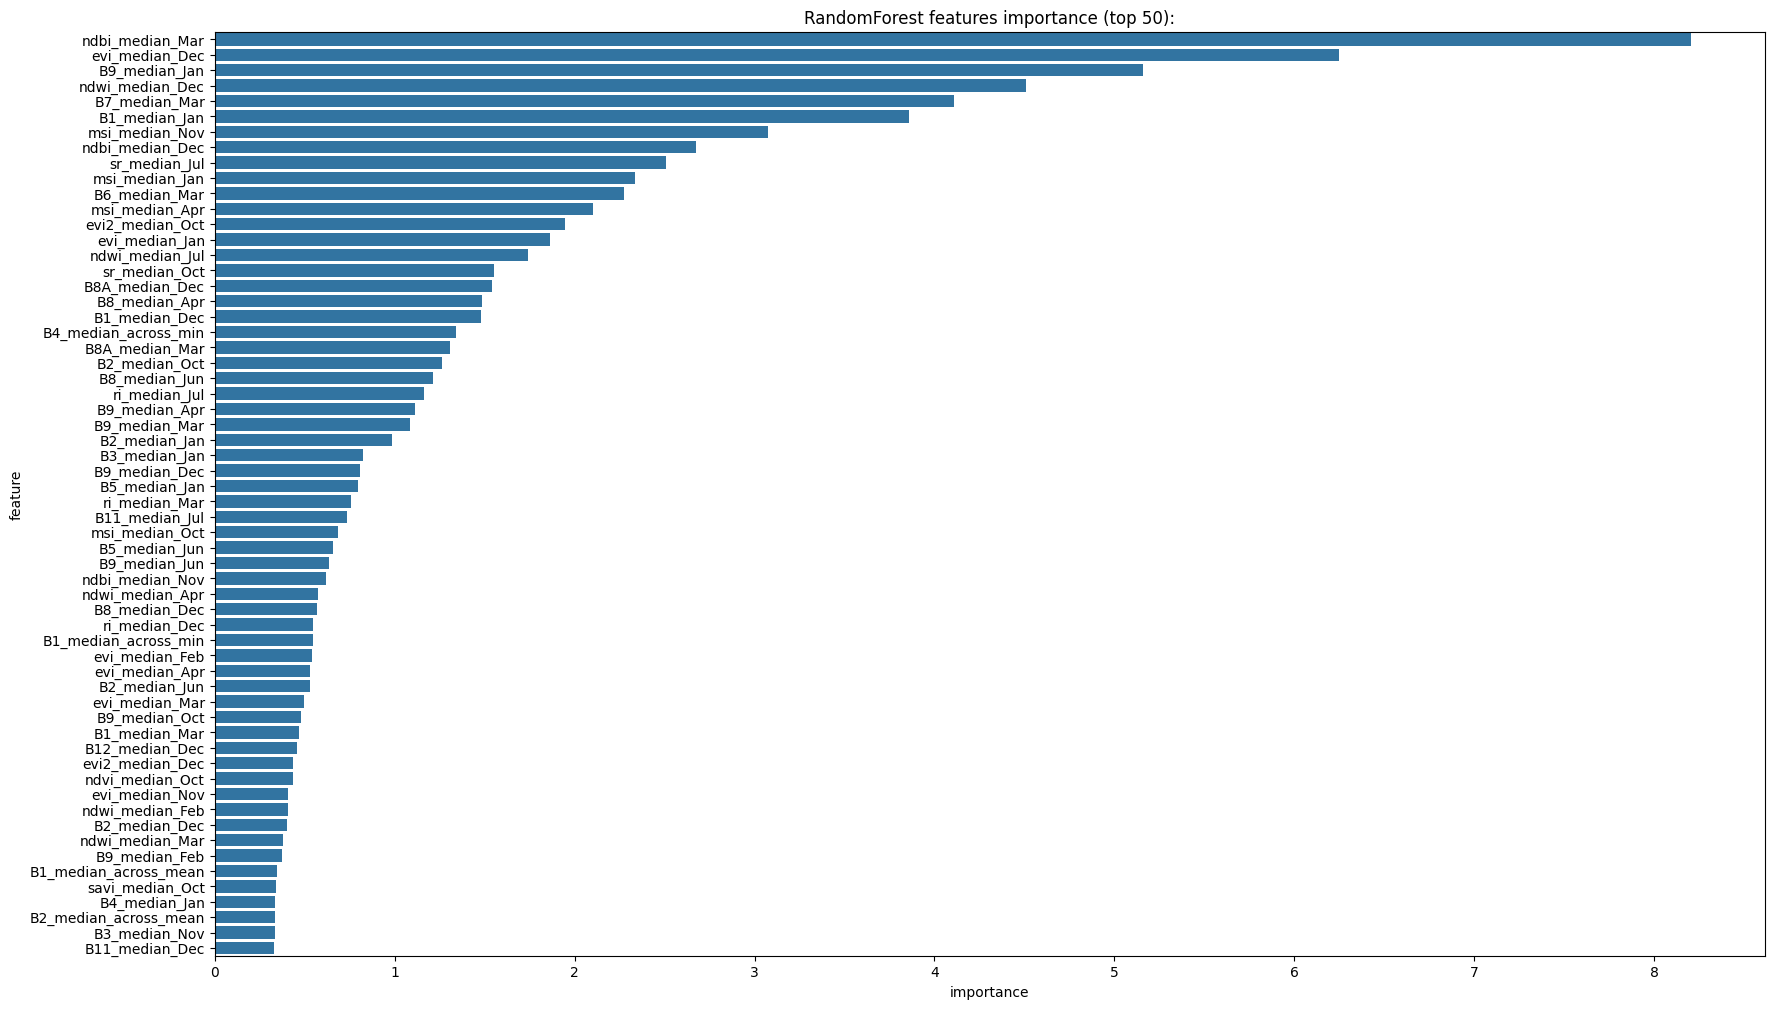

In [ ]:
feature_importance_df = pd.DataFrame(model.feature_importances_, columns=['importance'])
feature_importance_df['feature'] = list(set(features))

plt.figure(figsize=(20, 12));
sns.barplot(x="importance", y="feature", data=feature_importance_df.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('RandomForest features importance (top 50):')


In [ ]:
predicted_classes = np.argmax(test_predictions, axis =1)
len(predicted_classes), test.shape[0]

(282, 282)

In [ ]:
predicted_classes_orig = [list(le_name_mapping.keys())[list(le_name_mapping.values()).index(i)] for i in predicted_classes]


In [ ]:

test_df['Target'] = predicted_classes_orig
test_df[['ID', 'Target']].head()


,ID,Target
953,ID_731818,Palm
954,ID_790093,Rubber
955,ID_931033,Rubber
956,ID_079024,Rubber
957,ID_691532,Rubber


In [ ]:
test_df['Target'].value_counts()

,count
Target,
Rubber,125
Palm,102
Cocoa,55


In [ ]:
test_df[['ID', 'Target']].to_csv("submission_catboost_0_9644_5folds_patch_8.csv", index=False)

### LightGBM

In [ ]:
!mkdir -p /etc/OpenCL/vendors && echo "libnvidia-opencl.so.1" > /etc/OpenCL/vendors/nvidia.icd

In [ ]:
import numpy as np

target_col = 'crop'


scaler = RobustScaler()
def cross_validate_lgb_with_prob_saving(
    train_df,
    test_df,
    selected_columns,
    target_col,
    n_splits=5,
    random_state=87,
    model_prefix="lgb"
):
    params ={'learning_rate': 0.028240012565431134, 'num_leaves': 84, 'max_depth': 8,
             'min_data_in_leaf': 98, 'feature_fraction': 0.7936297724897203, 'bagging_fraction': 0.7670395572914223,
             'bagging_freq': 4, 'lambda_l1': 0.5250506638552409, 'lambda_l2': 0.9024542429647534,
          'objective': 'multiclass',
          'num_class': 3,
          'metric': 'multi_logloss',
          'verbosity': -1,
          'boosting_type': 'gbdt',

          }

    categorical_cols = [
        col for col in selected_columns
        if train_df[col].dtype == 'object' or train_df[col].dtype.name == 'category'
    ]

    num_classes = len(train_df[target_col].unique())

    oof_predictions = np.zeros((len(train_df),))
    oof_probabilities = np.zeros((len(train_df), num_classes))
    test_predictions = []

    fold_metrics = {
        'f1_scores': [],
        'accuracy_scores': [],
        'precision_scores': [],
        'recall_scores': []
    }

    oof_df_list = []
    test_df_list = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for fold, (train_index, val_index) in enumerate(skf.split(train_df[selected_columns], train_df[target_col])):
        print(f"\n{'='*50}")
        print(f"Fold {fold+1}/{n_splits}")
        print(f"{'='*50}")

        X_train = train_df.loc[train_index, selected_columns]
        y_train = train_df.loc[train_index, target_col]
        X_val = train_df.loc[val_index, selected_columns]
        y_val = train_df.loc[val_index, target_col]
        X_train_scaled = scaler.fit_transform(X_train[selected_columns])
        X_val_scaled = scaler.transform(X_val[selected_columns])
        X_test_scaled = scaler.transform(test_df[selected_columns])
        # X_train_scaled = X_train[selected_columns]
        # X_val_scaled = X_val[selected_columns]
        # X_test_scaled = test_df[selected_columns]


        model = lgb.LGBMClassifier(
            **params,
            n_estimators=1000,
            # num_bins=63,
            # device='gpu',
        )
        model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)])

        # Predict
        oof_probas = model.predict_proba(X_val_scaled)
        oof_preds = model.predict(X_val_scaled)
        test_probas = model.predict_proba(X_test_scaled)

        oof_predictions[val_index] = oof_preds.flatten()
        oof_probabilities[val_index] = oof_probas
        test_predictions.append(test_probas)

        # Save fold-wise OOF probabilities
        fold_oof_df = pd.DataFrame(oof_probas, columns=[f"{model_prefix}_fold{fold}_class{c}" for c in range(num_classes)])
        fold_oof_df["index"] = val_index
        oof_df_list.append(fold_oof_df)

        # Save fold-wise test probabilities
        fold_test_df = pd.DataFrame(test_probas, columns=[f"{model_prefix}_fold{fold}_class{c}" for c in range(num_classes)])
        test_df_list.append(fold_test_df)

        # Metrics
        f1 = f1_score(y_val, oof_preds, average='weighted')
        accuracy = accuracy_score(y_val, oof_preds)
        precision = precision_score(y_val, oof_preds, average='weighted')
        recall = recall_score(y_val, oof_preds, average='weighted')

        fold_metrics['f1_scores'].append(f1)
        fold_metrics['accuracy_scores'].append(accuracy)
        fold_metrics['precision_scores'].append(precision)
        fold_metrics['recall_scores'].append(recall)

        print(f"\nFold {fold+1} Metrics:")
        print(f"F1 Score: {f1:.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print("-"*50)

    print("\n" + "="*50)
    print("Overall Cross-Validation Performance")
    print("="*50)
    for metric, scores in fold_metrics.items():
        print(f"{metric.replace('_', ' ').title()}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

    print("\nClassification Report (OOF Predictions):")
    print(classification_report(train_df[target_col], oof_predictions))

    print("\nConfusion Matrix:")
    print(confusion_matrix(train_df[target_col], oof_predictions))

    # Save OOF Probabilities with ID
    oof_df = pd.concat(oof_df_list).sort_values("index").reset_index(drop=True)
    train_probs_with_ids = pd.concat([train_df[["ID"]].reset_index(drop=True), oof_df.drop(columns=["index"])], axis=1)
    train_probs_with_ids.to_csv(f"oof_{model_prefix}_probs.csv", index=False)

    # Save averaged test predictions with ID
    test_df_probs = pd.concat(test_df_list).groupby(level=0).mean()
    test_probs_with_ids = pd.concat([test_df[["ID"]].reset_index(drop=True), test_df_probs], axis=1)
    test_probs_with_ids.to_csv(f"test_{model_prefix}_probs.csv", index=False)

    results = {
        'oof_predictions': oof_predictions,
        'oof_probabilities': oof_probabilities,
        'test_predictions': np.mean(test_predictions, axis=0),
        'fold_metrics': fold_metrics,
        'model': model
    }

    return results

# ======== RUN TRAINING ==========

results = cross_validate_lgb_with_prob_saving(
    train_df=train_df,
    test_df=test_df,
    selected_columns=list(set(features)),
    target_col=target_col,
    n_splits=5,
    random_state=87,
    model_prefix="lgb"
)




Fold 1/5

Fold 1 Metrics:
F1 Score: 0.9843
Accuracy: 0.9843
Precision: 0.9850
Recall: 0.9843
--------------------------------------------------

Fold 2/5

Fold 2 Metrics:
F1 Score: 0.9582
Accuracy: 0.9581
Precision: 0.9595
Recall: 0.9581
--------------------------------------------------

Fold 3/5

Fold 3 Metrics:
F1 Score: 0.9427
Accuracy: 0.9424
Precision: 0.9448
Recall: 0.9424
--------------------------------------------------

Fold 4/5

Fold 4 Metrics:
F1 Score: 0.9582
Accuracy: 0.9579
Precision: 0.9594
Recall: 0.9579
--------------------------------------------------

Fold 5/5

Fold 5 Metrics:
F1 Score: 0.9789
Accuracy: 0.9789
Precision: 0.9789
Recall: 0.9789
--------------------------------------------------

Overall Cross-Validation Performance
F1 Scores: 0.9645 ± 0.0152
Accuracy Scores: 0.9643 ± 0.0153
Precision Scores: 0.9655 ± 0.0146
Recall Scores: 0.9643 ± 0.0153

Classification Report (OOF Predictions):
              precision    recall  f1-score   support

           0   

Text(0.5, 1.0, 'RandomForest features importance (top 50):')

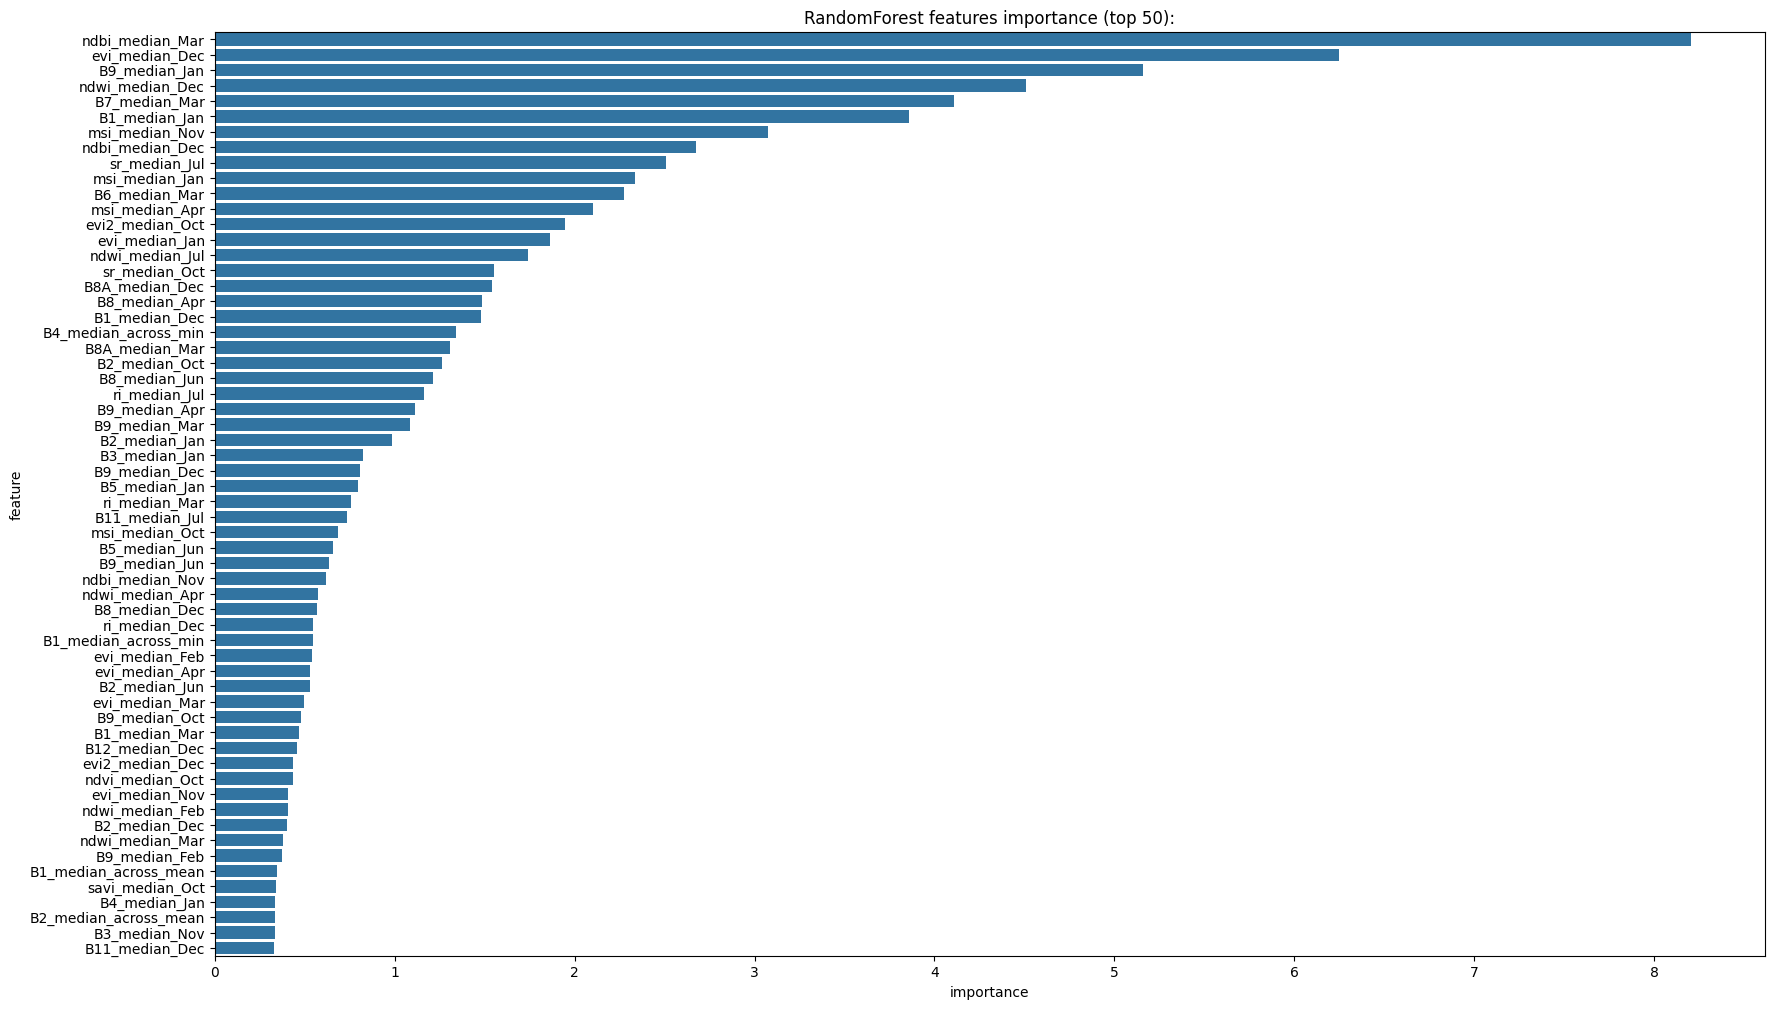

In [ ]:
feature_importance_df = pd.DataFrame(model.feature_importances_, columns=['importance'])
feature_importance_df['feature'] = list(set(features))

plt.figure(figsize=(20, 12));
sns.barplot(x="importance", y="feature", data=feature_importance_df.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('RandomForest features importance (top 50):')


In [ ]:
predicted_classes = np.argmax(results['test_predictions'], axis=1)

print(len(predicted_classes), test.shape[0])
predicted_classes_orig = [list(le_name_mapping.keys())[list(le_name_mapping.values()).index(i)] for i in predicted_classes]

test_df['Target'] = predicted_classes_orig
test_df[['ID', 'Target']].head()

print(test_df['Target'].value_counts())
test_df[['ID', 'Target']].to_csv("submission_lgb_0_9686_5folds_patch_8.csv", index=False)

282 282
Target
Rubber    127
Palm      101
Cocoa      54
Name: count, dtype: int64


In [ ]:
pd.read_csv("/content/test_lgb_probs.csv").head()

,ID,lgb_fold0_class0,lgb_fold0_class1,lgb_fold0_class2,lgb_fold1_class0,lgb_fold1_class1,lgb_fold1_class2,lgb_fold2_class0,lgb_fold2_class1,lgb_fold2_class2,lgb_fold3_class0,lgb_fold3_class1,lgb_fold3_class2,lgb_fold4_class0,lgb_fold4_class1,lgb_fold4_class2
0,ID_731818,0.002243,0.790781,0.206976,0.001195,0.578509,0.420296,0.005844,0.682915,0.311240,0.001855,0.907069,0.091075,0.002395,0.890819,0.106786
1,ID_790093,0.003406,0.093771,0.902823,0.001784,0.158799,0.839417,0.003942,0.241248,0.754810,0.004831,0.383962,0.611207,0.004231,0.179450,0.816319
2,ID_931033,0.060701,0.022067,0.917232,0.071167,0.147317,0.781517,0.038865,0.046139,0.914996,0.066084,0.039604,0.894313,0.075880,0.016641,0.907478
3,ID_079024,0.000116,0.000221,0.999664,0.000063,0.000460,0.999477,0.000082,0.000118,0.999800,0.000405,0.000213,0.999382,0.000047,0.000221,0.999732
4,ID_691532,0.007113,0.000891,0.991996,0.002745,0.001309,0.995946,0.003971,0.002079,0.993950,0.009258,0.002030,0.988712,0.021684,0.006877,0.971438


### XGB Classifier

In [ ]:

target_col = 'crop'
scaler = RobustScaler()

def cross_validate_xgboost(
    train_df,
    test_df,
    selected_columns,
    target_col,
    n_splits=5,
    random_state=87,
    model_prefix="xgb"
):
    params = {
       'learning_rate': 0.04563253856718224, 'max_depth': 12, 'min_child_weight': 8,
       'gamma': 0.20807486558259883, 'subsample': 0.6150300018236803,
       'colsample_bytree': 0.8322075370632999, 'lambda': 0.39921565114503976, 'alpha': 0.44618620389512953,
        'objective': 'multi:softprob',
        'num_class': train_df[target_col].nunique(),
        'eval_metric': 'mlogloss',
        'tree_method': 'gpu_hist',
        'predictor': 'gpu_predictor',
        'random_state': random_state,
        'verbosity': 0
    }

    num_classes = train_df[target_col].nunique()
    oof_predictions = np.zeros((len(train_df),))
    oof_probabilities = np.zeros((len(train_df), num_classes))
    test_predictions = []

    fold_metrics = {
        'f1_scores': [],
        'accuracy_scores': [],
        'precision_scores': [],
        'recall_scores': []
    }

    oof_df_list = []
    test_df_list = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for fold, (train_index, val_index) in enumerate(skf.split(train_df[selected_columns], train_df[target_col])):
        print(f"\n{'='*50}")
        print(f"Fold {fold+1}/{n_splits}")
        print(f"{'='*50}")

        X_train = train_df.loc[train_index, selected_columns]
        y_train = train_df.loc[train_index, target_col]
        X_val = train_df.loc[val_index, selected_columns]
        y_val = train_df.loc[val_index, target_col]
        # X_train_scaled = scaler.fit_transform(X_train[selected_columns])
        # X_val_scaled = scaler.transform(X_val[selected_columns])
        # X_test_scaled = scaler.transform(test_df[selected_columns])
        X_train_scaled = X_train[selected_columns]
        X_val_scaled = X_val[selected_columns]
        X_test_scaled = test_df[selected_columns]


        model = xgb.XGBClassifier(**params, n_estimators=1000)

        model.fit(
            X_train_scaled, y_train,
            eval_set=[(X_val_scaled, y_val)],
            verbose=False
        )

        oof_probas = model.predict_proba(X_val_scaled)
        oof_preds = model.predict(X_val_scaled)

        oof_predictions[val_index] = oof_preds.flatten()
        oof_probabilities[val_index] = oof_probas
        test_predictions.append(model.predict_proba(X_test_scaled))

        # Save OOF fold probabilities
        fold_oof_df = pd.DataFrame(oof_probas, columns=[f"{model_prefix}_fold{fold}_class{c}" for c in range(num_classes)])
        fold_oof_df["index"] = val_index
        oof_df_list.append(fold_oof_df)

        # Save test fold probabilities
        fold_test_df = pd.DataFrame(model.predict_proba(X_test_scaled),
                                    columns=[f"{model_prefix}_fold{fold}_class{c}" for c in range(num_classes)])
        test_df_list.append(fold_test_df)

        # Metrics
        f1 = f1_score(y_val, oof_preds, average='weighted')
        accuracy = accuracy_score(y_val, oof_preds)
        precision = precision_score(y_val, oof_preds, average='weighted')
        recall = recall_score(y_val, oof_preds, average='weighted')

        fold_metrics['f1_scores'].append(f1)
        fold_metrics['accuracy_scores'].append(accuracy)
        fold_metrics['precision_scores'].append(precision)
        fold_metrics['recall_scores'].append(recall)

        print(f"\nFold {fold+1} Metrics:")
        print(f"F1 Score: {f1:.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print("-"*50)

    print("\n" + "="*50)
    print("Overall Cross-Validation Performance")
    print("="*50)
    for metric, scores in fold_metrics.items():
        print(f"{metric.replace('_', ' ').title()}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

    print("\nClassification Report (OOF Predictions):")
    print(classification_report(train_df[target_col], oof_predictions))

    print("\nConfusion Matrix:")
    print(confusion_matrix(train_df[target_col], oof_predictions))

    # Save OOF and test probabilities
    oof_df = pd.concat(oof_df_list).sort_values("index").reset_index(drop=True)
    train_probs_with_ids = pd.concat([train_df[["ID"]].reset_index(drop=True), oof_df.drop(columns=["index"])], axis=1)
    train_probs_with_ids.to_csv(f"oof_{model_prefix}_probs.csv", index=False)

    test_df_probs = pd.concat(test_df_list).groupby(level=0).mean()
    test_probs_with_ids = pd.concat([test_df[["ID"]].reset_index(drop=True), test_df_probs], axis=1)
    test_probs_with_ids.to_csv(f"test_{model_prefix}_probs.csv", index=False)

    results = {
        'oof_predictions': oof_predictions,
        'oof_probabilities': oof_probabilities,
        'test_predictions': np.mean(test_predictions, axis=0),
        'fold_metrics': fold_metrics,
        'model': model
    }

    return results


# ======== RUN TRAINING ==========

results = cross_validate_xgboost(
    train_df=train_df,
    test_df=test_df,
    selected_columns=list(set(features)),
    target_col=target_col,
    n_splits=5,
    random_state=87,
    model_prefix="xgb"
)

# Save submission
predicted_classes = np.argmax(results['test_predictions'], axis=1)
predicted_classes_orig = [list(le_name_mapping.keys())[list(le_name_mapping.values()).index(i)] for i in predicted_classes]
test_df['Target'] = predicted_classes_orig

test_df[['ID', 'Target']].to_csv("submission_xgboost.csv", index=False)


# Access results
oof_predictions = results['oof_predictions']
test_predictions = results['test_predictions']
fold_metrics = results['fold_metrics']
model = results['model']



Fold 1/5

Fold 1 Metrics:
F1 Score: 0.9843
Accuracy: 0.9843
Precision: 0.9850
Recall: 0.9843
--------------------------------------------------

Fold 2/5

Fold 2 Metrics:
F1 Score: 0.9377
Accuracy: 0.9372
Precision: 0.9397
Recall: 0.9372
--------------------------------------------------

Fold 3/5

Fold 3 Metrics:
F1 Score: 0.9323
Accuracy: 0.9319
Precision: 0.9340
Recall: 0.9319
--------------------------------------------------

Fold 4/5

Fold 4 Metrics:
F1 Score: 0.9580
Accuracy: 0.9579
Precision: 0.9587
Recall: 0.9579
--------------------------------------------------

Fold 5/5

Fold 5 Metrics:
F1 Score: 0.9633
Accuracy: 0.9632
Precision: 0.9639
Recall: 0.9632
--------------------------------------------------

Overall Cross-Validation Performance
F1 Scores: 0.9551 ± 0.0187
Accuracy Scores: 0.9549 ± 0.0189
Precision Scores: 0.9563 ± 0.0182
Recall Scores: 0.9549 ± 0.0189

Classification Report (OOF Predictions):
              precision    recall  f1-score   support

           0   

In [ ]:
predicted_classes = np.argmax(test_predictions, axis =1)
print(len(predicted_classes), test.shape[0])
predicted_classes_orig = [list(le_name_mapping.keys())[list(le_name_mapping.values()).index(i)] for i in predicted_classes]

test_df['Target'] = predicted_classes_orig
test_df[['ID', 'Target']].head()

print(test_df['Target'].value_counts())
test_df[['ID', 'Target']].to_csv("submission_xgb_0_9603_5folds_patch_8.csv", index=False)

282 282
Target
Rubber    127
Palm      102
Cocoa      53
Name: count, dtype: int64


### ENSEMBLING

In [ ]:
cat_preds = pd.read_csv("/content/test_cat_probs.csv")
lgb_preds = pd.read_csv("/content/test_lgb_probs.csv")
xgb_preds = pd.read_csv("/content/test_xgb_probs.csv")

display(cat_preds.head(), lgb_preds.head(), xgb_preds.head())

,ID,cat_fold0_class0,cat_fold0_class1,cat_fold0_class2,cat_fold1_class0,cat_fold1_class1,cat_fold1_class2,cat_fold2_class0,cat_fold2_class1,cat_fold2_class2,cat_fold3_class0,cat_fold3_class1,cat_fold3_class2,cat_fold4_class0,cat_fold4_class1,cat_fold4_class2
0,ID_731818,0.002645,0.888975,0.108379,0.001443,0.879747,0.118810,0.004499,0.761904,0.233597,0.001992,0.892973,0.105036,0.001540,0.940662,0.057798
1,ID_790093,0.001196,0.066704,0.932099,0.001283,0.060503,0.938214,0.003596,0.339770,0.656634,0.003635,0.149200,0.847165,0.003250,0.327969,0.668782
2,ID_931033,0.009254,0.183189,0.807557,0.007156,0.473069,0.519775,0.015971,0.322907,0.661122,0.010583,0.279876,0.709541,0.010261,0.144366,0.845372
3,ID_079024,0.000191,0.000881,0.998928,0.000150,0.000556,0.999294,0.000279,0.001067,0.998654,0.000381,0.001174,0.998445,0.000189,0.000810,0.999001
4,ID_691532,0.001263,0.002420,0.996317,0.000573,0.001450,0.997978,0.001311,0.003417,0.995272,0.001768,0.002581,0.995651,0.001204,0.001198,0.997597


,ID,lgb_fold0_class0,lgb_fold0_class1,lgb_fold0_class2,lgb_fold1_class0,lgb_fold1_class1,lgb_fold1_class2,lgb_fold2_class0,lgb_fold2_class1,lgb_fold2_class2,lgb_fold3_class0,lgb_fold3_class1,lgb_fold3_class2,lgb_fold4_class0,lgb_fold4_class1,lgb_fold4_class2
0,ID_731818,0.002243,0.790781,0.206976,0.001195,0.578509,0.420296,0.005844,0.682915,0.311240,0.001855,0.907069,0.091075,0.002395,0.890819,0.106786
1,ID_790093,0.003406,0.093771,0.902823,0.001784,0.158799,0.839417,0.003942,0.241248,0.754810,0.004831,0.383962,0.611207,0.004231,0.179450,0.816319
2,ID_931033,0.060701,0.022067,0.917232,0.071167,0.147317,0.781517,0.038865,0.046139,0.914996,0.066084,0.039604,0.894313,0.075880,0.016641,0.907478
3,ID_079024,0.000116,0.000221,0.999664,0.000063,0.000460,0.999477,0.000082,0.000118,0.999800,0.000405,0.000213,0.999382,0.000047,0.000221,0.999732
4,ID_691532,0.007113,0.000891,0.991996,0.002745,0.001309,0.995946,0.003971,0.002079,0.993950,0.009258,0.002030,0.988712,0.021684,0.006877,0.971438


,ID,xgb_fold0_class0,xgb_fold0_class1,xgb_fold0_class2,xgb_fold1_class0,xgb_fold1_class1,xgb_fold1_class2,xgb_fold2_class0,xgb_fold2_class1,xgb_fold2_class2,xgb_fold3_class0,xgb_fold3_class1,xgb_fold3_class2,xgb_fold4_class0,xgb_fold4_class1,xgb_fold4_class2
0,ID_731818,0.008598,0.785627,0.205775,0.010368,0.577536,0.412096,0.017791,0.580422,0.401786,0.009579,0.712426,0.277996,0.008537,0.740649,0.250814
1,ID_790093,0.025986,0.123747,0.850267,0.010700,0.129374,0.859926,0.021966,0.311729,0.666304,0.022150,0.398339,0.579510,0.030990,0.227910,0.741100
2,ID_931033,0.095358,0.080319,0.824323,0.123482,0.325926,0.550591,0.075544,0.117622,0.806834,0.074015,0.073481,0.852504,0.081486,0.053182,0.865332
3,ID_079024,0.000717,0.000670,0.998613,0.000874,0.000822,0.998305,0.000573,0.000367,0.999060,0.001744,0.000718,0.997538,0.000505,0.000511,0.998984
4,ID_691532,0.021992,0.007229,0.970779,0.003618,0.003043,0.993339,0.007740,0.003042,0.989218,0.011063,0.005122,0.983815,0.013278,0.006648,0.980074


In [ ]:
# Extract average class probabilities over folds
def get_avg_probs(df, prefix):
    class_cols = [col for col in df.columns if col.startswith(prefix)]
    probs = df[class_cols].values.reshape(len(df), -1, 3)  # (n_samples, n_folds, n_classes)
    return probs.mean(axis=1)  # (n_samples, n_classes)

In [ ]:

class_map = {v: k for k, v in le_name_mapping.items()}
class_map

{np.int64(0): 'Cocoa', np.int64(1): 'Palm', np.int64(2): 'Rubber'}

In [ ]:
import pandas as pd
import numpy as np

# Load files
cat = pd.read_csv("/content/test_cat_probs.csv")
lgb = pd.read_csv("/content/test_lgb_probs.csv")
xgb = pd.read_csv("/content/test_xgb_probs.csv")

# Sort to ensure alignment
cat = cat.sort_values("ID").reset_index(drop=True)
lgb = lgb.sort_values("ID").reset_index(drop=True)
xgb = xgb.sort_values("ID").reset_index(drop=True)


# Get IDs
ids = cat["ID"]

cat_avg = get_avg_probs(cat, "cat_fold")
lgb_avg = get_avg_probs(lgb, "lgb_fold")
xgb_avg = get_avg_probs(xgb, "xgb_fold")

#pdb.set_trace()
ens = (lgb_avg + cat_avg + xgb_avg) / 3

# Get class predictions
ens_classes = np.argmax(ens, axis=1)

ens_df = pd.DataFrame({
    'ID': ids,
    'Target': ens_classes
})
ens_df['Target'] = ens_df['Target'].map(class_map)
ens_df.to_csv("lgb_cat_xgb_ensemble.csv", index=False)

In [ ]:
ens_df['Target'].value_counts()

,count
Target,
Rubber,126
Palm,102
Cocoa,54


Rubber	126<br>
Palm	102<br>
Cocoa	54<br>
